**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 06 Nov 2025**
<br>
**Lab - 19**
<br>

In [12]:
import tensorflow as tf
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Data Pre-processing: 
o Load the MNIST dataset using tensorflow.keras.datasets. 
o Flatten the 28x28 images to 784-length vectors. 
o Normalize pixel values between 0 and 1 using StandardScaler.

In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [14]:
n_samples = 1000
X = X_train[:n_samples]
y = y_train[:n_samples]
X_flat = X.reshape(n_samples, -1).astype(float)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

Use PCA to reduce dimensions from 784 to 2. 
o Display explained variance ratio for the top 2 components. 
o Comment on the total variance retained. 

In [16]:
n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [17]:
explained_variance_ratio = pca.explained_variance_ratio_
total_variance_retained = np.sum(explained_variance_ratio)

print("\n--- PCA Results (784 -> 2 Dimensions) ---")
print(f"Explained Variance Ratio (PC1): {explained_variance_ratio[0]:.4f}")
print(f"Explained Variance Ratio (PC2): {explained_variance_ratio[1]:.4f}")


--- PCA Results (784 -> 2 Dimensions) ---
Explained Variance Ratio (PC1): 0.0649
Explained Variance Ratio (PC2): 0.0548


Plot the 2D PCA-transformed data using a scatter plot. 
o Use color to distinguish between digit classes (0–9)

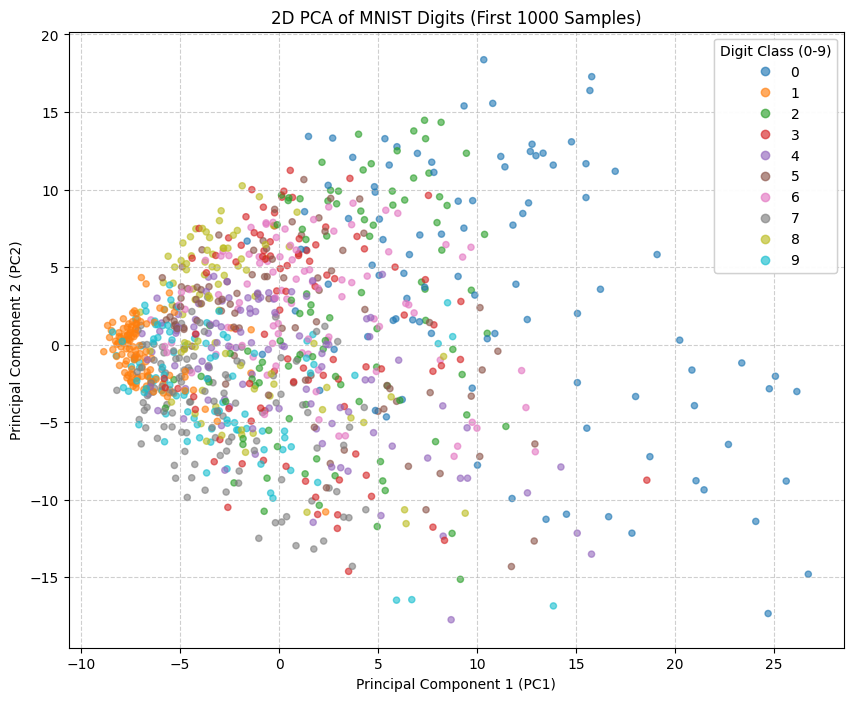

In [18]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, s=20) 
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('2D PCA of MNIST Digits (First 1000 Samples)')

legend1 = plt.legend(*scatter.legend_elements(), title="Digit Class (0-9)", loc="upper right")
plt.gca().add_artist(legend1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Reconstruct the original images from the 2D components. 
o Calculate Mean Squared Error (MSE) between the original and 
reconstructed images. 
 

In [19]:
X_reconstructed_scaled = pca.inverse_transform(X_pca)
X_reconstructed_flat = scaler.inverse_transform(X_reconstructed_scaled)
X_reconstructed_flat[X_reconstructed_flat < 0] = 0
X_reconstructed_flat[X_reconstructed_flat > 255] = 255
mse = mean_squared_error(X_flat, X_reconstructed_flat)
print(f"\nMean Squared Error (MSE) between Original and Reconstructed Images: {mse:.4f}")


Mean Squared Error (MSE) between Original and Reconstructed Images: 3621.4012
